In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("ecommerce_customer_churn_messy.csv")
df.head()
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [3]:
df = pd.read_csv("ecommerce_customer_churn_messy.csv")

df.head()

,customer_id,signup_date,gender,customer_age,country,city,customer_segment,membership_type,acquisition_channel,payment_method,preferred_device,product_category,subscription_type,subscription_start,subscription_end,annual_income,account_balance,total_spending,average_order_value,number_of_orders,days_since_last_order,last_purchase_date,last_login,website_visits,support_tickets,discount_usage,refund_amount,lifetime_value,cancellation_reason,cancellation_date,final_account_status,churn
0,116825,15/03/2023,Female,25,Mexico,-,At Risk,Basic,Social Media,CC,mobile,Fashion,NaN,NaN,NaN,40073.163889158524,31.45493464429578,244 USD,76.51248933748424,3,204,Dec 08 2024,2025/02/14,11,5,na,304.07451924393416,161.49335535714303,NaN,NaN,Active,0
1,120989,23-Dec-2021,MALE,33,Australia,Sydney,At Risk,NaN,Affiliate,NaN,Mobile,Books,Monthly,2024/01/13,2024-02-12,22.0k,-33.93575364685871,530.5079689869871,93.73281367396993,5,22,2025-06-08,2025/06/25,4,6,NaN,72.85522286723364,513.0027487578841,Lack of use,2025/07/31,Cancelled,1
2,114224,09/30/2022,f,53,France,Paris,VIP,platinum,Affiliate,GiftCard,MOBILE,Beauty,Annual,2023-11-28,2026/11/27,28495.716281342342,689.6095108147844,"1,351.29",168.9460007500417,9,81,2025-04-10,NaN,29,3,1,13.242879654798044,1726.2619113783849,NaN,NaN,Active,0
3,105434,2019-07-31,FEMALE,38,Germany,Hamburg,Regular,GOLD,Email Campaign,GiftCard,mobile,Beauty,Annual,11/30/2020,30/11/2022,59384.09928209819,809.3229133956987,2546.94557029017,59.4678614474072,36,13,Jun 17 2025,2025-06-26,42,1,1,0.5099317859104724,2558.118216316428,NaN,NaN,Active,1
4,114108,2020/09/17,m,41,France,Marseille,Regular,BASIC,Organic Search,debit_card,desktop,Home & Garden,Monthly,24/06/2024,09/22/2024,"83,009.98",708.77,931.7579074858828,46.15379163314423,20,7,Jun 23 2025,2025-06-21,37,5,0,35.58539763461529,1087.3376248567533,NaN,NaN,Active,0


In [4]:
df.shape

(22080, 32)

In [5]:
df.columns.tolist()

['customer_id',
 'signup_date',
 'gender',
 'customer_age',
 'country',
 'city',
 'customer_segment',
 'membership_type',
 'acquisition_channel',
 'payment_method',
 'preferred_device',
 'product_category',
 'subscription_type',
 'subscription_start',
 'subscription_end',
 'annual_income',
 'account_balance',
 'total_spending',
 'average_order_value',
 'number_of_orders',
 'days_since_last_order',
 'last_purchase_date',
 'last_login',
 'website_visits',
 'support_tickets',
 'discount_usage',
 'refund_amount',
 'lifetime_value',
 'cancellation_reason',
 'cancellation_date',
 'final_account_status',
 'churn']

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 22080 entries, 0 to 22079
Data columns (total 32 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   customer_id            22080 non-null  int64
 1   signup_date            22080 non-null  str  
 2   gender                 21358 non-null  str  
 3   customer_age           21458 non-null  str  
 4   country                22080 non-null  str  
 5   city                   21193 non-null  str  
 6   customer_segment       21458 non-null  str  
 7   membership_type        21490 non-null  str  
 8   acquisition_channel    21232 non-null  str  
 9   payment_method         21346 non-null  str  
 10  preferred_device       21126 non-null  str  
 11  product_category       21508 non-null  str  
 12  subscription_type      15351 non-null  str  
 13  subscription_start     15346 non-null  str  
 14  subscription_end       15614 non-null  str  
 15  annual_income          20786 non-null  str  
 1

In [7]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,22080.0,NaN,NaN,NaN,110751.930525,6204.831301,100000.0,105388.75,110762.5,116115.25,121499.0
signup_date,22080,10315,2024-13-45,39,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,21358,24,female,1751,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_age,21458,78,16,822,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,22080,84,Brazil,1636,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,21193,228,Sao Paulo,548,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_segment,21458,24,Regular,7123,NaN,NaN,NaN,NaN,NaN,NaN,NaN
membership_type,21490,68,basic,1849,NaN,NaN,NaN,NaN,NaN,NaN,NaN
acquisition_channel,21232,28,Organic Search,3033,NaN,NaN,NaN,NaN,NaN,NaN,NaN
payment_method,21346,80,Gift Card,1272,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": df.isnull().mean() * 100
})

missing_summary = missing_summary.sort_values(
    "missing_count",
    ascending=False
)

missing_summary

,missing_count,missing_percent
cancellation_date,17307,78.383152
cancellation_reason,17307,78.383152
subscription_start,6734,30.498188
subscription_type,6729,30.475543
subscription_end,6466,29.284420
final_account_status,4384,19.855072
refund_amount,1423,6.444746
last_purchase_date,1382,6.259058
annual_income,1294,5.860507
discount_usage,1033,4.678442


In [9]:
missing_summary.head(5)

,missing_count,missing_percent
cancellation_date,17307,78.383152
cancellation_reason,17307,78.383152
subscription_start,6734,30.498188
subscription_type,6729,30.475543
subscription_end,6466,29.284420


In [10]:
df.duplicated().sum()

np.int64(368)

In [11]:
df["churn"].value_counts(normalize=True) * 100

churn
0    74.388587
1    25.611413
Name: proportion, dtype: float64

In [12]:
df = df.drop_duplicates()

In [13]:
df.shape

(21712, 32)

In [14]:
# FIX: added "-" to the missing-token list (it was leaking through as a real
# category before, e.g. in city / customer_segment / payment_method)
missing_tokens = [
    "",
    "na",
    "n/a",
    "nan",
    "null",
    "none",
    "unknown",
    "?",
    "-"
]

for col in df.select_dtypes(include=["object", "string"]).columns:
    df[col] = (
        df[col]
        .astype("string")
        .str.strip()
        .str.lower()
    )

    df[col] = df[col].replace(
        missing_tokens,
        np.nan
    )

In [15]:
gender_map = {
    "female": "Female",
    "f": "Female",
    "male": "Male",
    "m": "Male"
}

df["gender"] = df["gender"].map(gender_map)

df["gender"].value_counts(dropna=False)

gender
Female    9874
Male      9741
NaN       2097
Name: count, dtype: int64

In [16]:
membership_map = {
    "basic": "Basic",
    "premium": "Premium",
    "gold": "Gold",
    "platinum": "Platinum"
}

df["membership_type"] = (
    df["membership_type"]
    .map(membership_map)
)

df["membership_type"].value_counts(dropna=False)

membership_type
Basic       8094
Premium     6886
Gold        4344
Platinum    1300
NaN         1088
Name: count, dtype: int64

In [17]:
# NEW: your "country" column had 5 spellings of the US and 4 of the UK
# (e.g. "usa", "us", "u.s.a.", "united states", "united states of america"
# all meant the same country). Collapse them to one canonical label.
country_map = {
    "usa": "united states",
    "us": "united states",
    "u.s.a.": "united states",
    "united states": "united states",
    "united states of america": "united states",
    "uk": "united kingdom",
    "u.k.": "united kingdom",
    "britain": "united kingdom",
    "united kingdom": "united kingdom",
}

df["country"] = df["country"].replace(country_map)

df["country"].value_counts(dropna=False)

country
mexico            1849
united states     1842
united kingdom    1838
brazil            1837
australia         1830
canada            1829
france            1821
italy             1809
japan             1787
india             1777
spain             1761
germany           1732
Name: count, dtype: Int64

In [18]:
# NEW: "payment_method" had 16 different spellings for ~5 real categories
# (e.g. "cc", "credit card", "credit_card", "creditcard" are all the same
# thing). Normalize by stripping spaces/underscores, then map.
def normalize_payment_method(value):
    if pd.isna(value):
        return np.nan

    key = value.replace("_", "").replace(" ", "")

    payment_map = {
        "creditcard": "credit card",
        "cc": "credit card",
        "debitcard": "debit card",
        "dc": "debit card",
        "banktransfer": "bank transfer",
        "giftcard": "gift card",
        "paypal": "paypal",
    }

    return payment_map.get(key, value)

df["payment_method"] = df["payment_method"].apply(normalize_payment_method)

df["payment_method"].value_counts(dropna=False)

payment_method
gift card        4189
debit card       4096
credit card      4078
bank transfer    4069
paypal           4027
NaN              1253
Name: count, dtype: int64

In [19]:
def parse_number(value):

    if pd.isna(value):
        return np.nan

    value = str(value).strip().lower()

    if value in [
        "",
        "na",
        "n/a",
        "nan",
        "null",
        "none",
        "unknown",
        "?",
        "-"
    ]:
        return np.nan

    value = value.replace(",", "")
    value = value.replace("$", "")
    value = value.replace("usd", "").strip()

    try:

        if value.endswith("k"):
            return float(value[:-1]) * 1_000

        if value.endswith("m"):
            return float(value[:-1]) * 1_000_000

        return float(value)

    except ValueError:
        return np.nan

In [20]:
# FIX: added "account_balance" - it was never parsed/validated in the
# original pipeline, which is why it still had ~4,600 negative values
# and inconsistent formatting after "cleaning".
numeric_columns = [
    "customer_age",
    "annual_income",
    "account_balance",
    "total_spending",
    "average_order_value",
    "number_of_orders",
    "days_since_last_order",
    "website_visits",
    "support_tickets",
    "discount_usage",
    "refund_amount",
    "lifetime_value"
]

for col in numeric_columns:
    df[col] = df[col].apply(parse_number)

In [21]:
df[numeric_columns].dtypes

customer_age             float64
annual_income            float64
account_balance          float64
total_spending           float64
average_order_value      float64
number_of_orders         float64
days_since_last_order    float64
website_visits           float64
support_tickets          float64
discount_usage           float64
refund_amount            float64
lifetime_value           float64
dtype: object

In [22]:
df.loc[
    ~df["customer_age"].between(18, 100),
    "customer_age"
] = np.nan

In [23]:
# FIX: added "account_balance". A negative balance CAN be legitimate
# (e.g. an amount owed), but ~21% of rows were negative here, which is far
# more consistent with a data-entry/sign bug than genuine debt. If your
# business logic says negative balances are valid, drop this column from
# the list below.
non_negative_columns = [
    "annual_income",
    "account_balance",
    "total_spending",
    "average_order_value",
    "number_of_orders",
    "days_since_last_order",
    "website_visits",
    "support_tickets",
    "discount_usage",
    "refund_amount",
    "lifetime_value"
]

for col in non_negative_columns:
    df.loc[df[col] < 0, col] = np.nan

In [24]:
date_columns = [
    "signup_date",
    "subscription_start",
    "subscription_end",
    "last_purchase_date",
    "last_login",
    "cancellation_date"
]

for col in date_columns:
    df[col] = pd.to_datetime(
        df[col],
        format="mixed",
        errors="coerce"
    )

In [25]:
df[date_columns].isnull().sum()

signup_date             184
subscription_start     7143
subscription_end       6470
last_purchase_date     2425
last_login             1434
cancellation_date     17059
dtype: int64

In [26]:
reference_date = pd.Timestamp("2025-07-01")

df["days_since_login"] = (
    reference_date - df["last_login"]
).dt.days

df["days_since_purchase"] = (
    reference_date - df["last_purchase_date"]
).dt.days

df["customer_tenure_days"] = (
    reference_date - df["signup_date"]
).dt.days

df["subscription_duration_days"] = (
    df["subscription_end"]
    - df["subscription_start"]
).dt.days

# FIX: these four columns came out with negative values in the original
# cleaned file (e.g. a signup_date after the reference_date, or a
# subscription_end before subscription_start). Both indicate bad/impossible
# dates rather than valid data, so null them out instead of keeping them.
day_diff_columns = [
    "days_since_login",
    "days_since_purchase",
    "customer_tenure_days",
    "subscription_duration_days"
]

for col in day_diff_columns:
    df.loc[df[col] < 0, col] = np.nan

In [27]:
# NEW: a handful of numeric columns have extreme, implausible maxima
# (e.g. annual_income up to ~8.9M vs a median around 40K; website_visits
# up to ~19,858 vs a median of 25). Winsorize the top 1% instead of
# deleting rows, so a handful of bad values don't dominate model training.
outlier_columns = [
    "annual_income",
    "total_spending",
    "average_order_value",
    "number_of_orders",
    "website_visits",
    "lifetime_value",
    "refund_amount"
]

for col in outlier_columns:
    cap = df[col].quantile(0.99)
    df[col] = df[col].clip(upper=cap)

In [28]:
df["orders_per_visit"] = (
    df["number_of_orders"] /
    df["website_visits"].replace(0, np.nan)
)

df["spending_per_order"] = (
    df["total_spending"] /
    df["number_of_orders"].replace(0, np.nan)
)

df["refund_rate"] = (
    df["refund_amount"] /
    df["total_spending"].replace(0, np.nan)
)

df["support_tickets_per_order"] = (
    df["support_tickets"] /
    df["number_of_orders"].replace(0, np.nan)
)

In [29]:
leakage_columns = [
    "cancellation_reason",
    "cancellation_date",
    "final_account_status"
]

df = df.drop(
    columns=leakage_columns
)

In [30]:
df = df.drop(
    columns=["customer_id"]
)

In [31]:
raw_date_columns = [
    "signup_date",
    "subscription_start",
    "subscription_end",
    "last_purchase_date",
    "last_login"
]

df = df.drop(
    columns=raw_date_columns
)

In [32]:
df.shape

(21712, 31)

In [33]:
df.columns.tolist()

['gender',
 'customer_age',
 'country',
 'city',
 'customer_segment',
 'membership_type',
 'acquisition_channel',
 'payment_method',
 'preferred_device',
 'product_category',
 'subscription_type',
 'annual_income',
 'account_balance',
 'total_spending',
 'average_order_value',
 'number_of_orders',
 'days_since_last_order',
 'website_visits',
 'support_tickets',
 'discount_usage',
 'refund_amount',
 'lifetime_value',
 'churn',
 'days_since_login',
 'days_since_purchase',
 'customer_tenure_days',
 'subscription_duration_days',
 'orders_per_visit',
 'spending_per_order',
 'refund_rate',
 'support_tickets_per_order']

In [34]:
df.dtypes

gender                            str
customer_age                  float64
country                        string
city                           string
customer_segment               string
membership_type                   str
acquisition_channel            string
payment_method                    str
preferred_device               string
product_category               string
subscription_type              string
annual_income                 float64
account_balance               float64
total_spending                float64
average_order_value           float64
number_of_orders              float64
days_since_last_order         float64
website_visits                float64
support_tickets               float64
discount_usage                float64
refund_amount                 float64
lifetime_value                float64
churn                           int64
days_since_login              float64
days_since_purchase           float64
customer_tenure_days          float64
subscription

In [35]:
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": df.isnull().mean() * 100
}).sort_values(
    "missing_count",
    ascending=False
)

missing_summary

,missing_count,missing_percent
subscription_duration_days,7561,34.824060
subscription_type,7126,32.820560
account_balance,6111,28.145726
days_since_purchase,2885,13.287583
refund_rate,2848,13.117170
refund_amount,2534,11.670965
lifetime_value,2517,11.592668
annual_income,2231,10.275424
customer_age,2197,10.118828
gender,2097,9.658254


In [36]:
# sanity check: confirm no duplicates or impossible negatives slipped
# back in after the derived-column steps
print("duplicate rows:", df.duplicated().sum())

check_non_negative = non_negative_columns + day_diff_columns
for col in check_non_negative:
    n_neg = (df[col] < 0).sum()
    if n_neg > 0:
        print(f"WARNING: {col} still has {n_neg} negative values")

print("check complete")

duplicate rows: 111
check complete


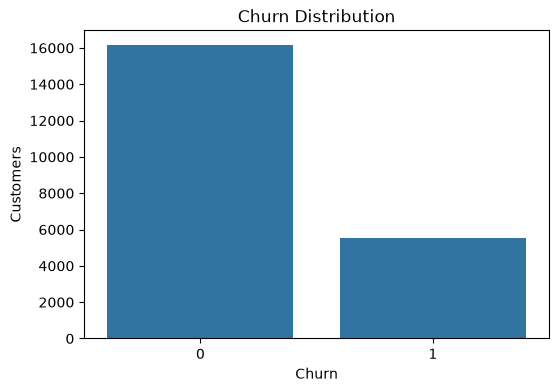

In [37]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="churn"
)

plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Customers")

plt.show()

In [38]:
df.to_csv("Cleaned_Data.csv", index=False)